
# Disaster Response Plan Optimization

**Prepared by:** Pauline Wang (pwang7@nd.edu, 2024) and Mariam Jafri (mjafri@nd.edu, 2024)

By the end of this project, we hope to:

*   Gain experience in defining and evaluating optimization problems manually.
*   Build skills in Python programming and using the Pyomo library.
*   Interpret and communicate findings from disaster response plan optimization

## Preamble: Install Pyomo and a solver


We consolidated the package installation commands for pyomo and highspy into a single line and grouped the imports for improved readability, but we made no significant changes to the functionality of the original code from the original source.

In [1]:
import sys

if "google.colab" in sys.modules:
    # %pip install pyomo highspy >/dev/null 2>/dev/null
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

    # Import solvers
    import idaes
helper.set_plotting_style()

import pyomo.environ as pyo

# solver = 'appsi_highs'
# SOLVER = pyo.SolverFactory(solver)
# assert SOLVER.available(), f"Solver {solver} is not available."

# Additional imports
import random
import numpy as np
import matplotlib.pyplot as plt

# import highspy

# Seed the random number generator so this notebook is reproducible
# (Pyomo style guide, section 8).
np.random.seed(0)
random.seed(0)

## Problem Definition






This problem focuses on optimizing the distribution of supplies to various regions over time in response to their needs during disasters. The goal is to minimize the difference between the demand for supplies in each region and the actual supplies consumed, while accounting for constraints such as storage levels, supply limits, and dynamic inventory updates. The model considers factors like danger levels, and positions of regions. The model also ensures that supply storage and distribution quantities remain non-negative.


## Description

This optimization problem is inspired by disaster relief plans, where we aim to determine the most efficient disaster response system, taking into consideration the severity of the disaster, the level of need, and the available inventory of supplies. Accordingly, this project develops the optimization model from scratch using simulation, of which the data is hypothetical.


## Optimization Model Typeset



Sets:
- Time intervals and Regions are sets modeled by:

$$
  t = {1,...N_t}
  \\
  R = {1,....N_R}
$$

Data:

- supplies needed in region k at time t is modeled by:

$$
  S_{k,t} ≥ 0
$$

- danger is modeled by

$$
  d_{k,t} ≥ 0
$$

- position of region k is modeled by

$$
  p_{k} ≥ 0
$$

Decisions:

- amount of supplies distributed to region k at time t

$$
  x_{k,t} ≥ 0
$$

- amount of supplies stored in region k at time t

$$
  I_{k,t} ≥ 0
$$

Objective:

- minimizing difference between demand for a region k at time t and the supplies consumed for that region at that time

$$
  \min ∑∑s̄_{k,t} - s_{k,t}
$$


Constraints:
- updated storage for region k at time t is dependent on storage for region k and time t-1, subtracted by the supplies being consumed at region k at time t, plus the amount of supplies distributed to region k at time t

$$
  I_{k,t} = I_{k,t-1} - S_{k,t} + x_{k,t}
$$

- amount consumed for region k at time t will always be greater than 0 and less than the demand for that region

$$
  0 ≤ S_{k,t} ≤ s̄_{k,t}
$$

- Inventory of a region k at time t must never go below 0 and amount of supplies distributed must never go below 0

$$
  I_{k,t} ≥ 0, \space x_{k,t} ≥ 0
$$


## Degree of Freedom Analysis


In this model, there are three decision variables for each region and time interval:
1. $x_{k,t}$ (supplies distributed)
2. $I_{k,t}$ (supplies stored)
3. $S_{k,t}$ (supplies consumed).

This results in a total of \(3 \times (N_R \times N_t)\) decision variables, where \(N_R\) is the number of regions and \(N_t\) is the number of time intervals. The inventory update rule introduces one equality constraint for each region and time interval, giving \(N_R \times N_t\) equality constraints. Therefore, the degree of freedom is calculated as:

$$
DOF = 3 \times (N_R \times N_t) - (N_R \times N_t) = 2 \times (N_R \times N_t).
$$



## Optimization Model Implemented

In [2]:
def m_model(
    S_needed_data, d_data, p_data, I_initial_data, N_t, N_R, print_verbose=True
):
    """

    Build and solve an optimization model for disaster response planning.

    Parameters:
    - S_needed (dict): Supplies needed in each region at each time, represented as a dictionary with keys (region, time).
    - d (float): Danger level associated with each region, which may influence prioritization of supply distribution.
    - p (float): Position or proximity of each region, potentially impacting logistical considerations.
    - I_initial (dict): Initial inventory levels in each region, represented as a dictionary with keys (region).
    - N_t (int): Number of timesteps
    - N_R (int): Number of regions

    Decision Variables:
    - x_i: amount of supplies s at region R at time t

    Objective:
    -  minimizing difference between demand for a region k at time t and the supplies consumed for that region at that time,
        calcuated as ∑∑s̄_{k,t} - s_{k,t}

    Constraints:
    - updated storage for region k at time t is dependent on storage for region k and time t-1, subtracted by the supplies being consumed at region k at time t, plus the amount of supplies distributed to region k at time t
      I_{k,t} = I_{k,t-1} - S_{k,t} + x_{k,t}

    - amount consumed for region k at time t will always be greater than 0 and less than the demand for that region
      0 ≤ S_{k,t} ≤ s̄_{k,t}

    Returns:
    - model: The Pyomo ConcreteModel instance containing the defined objective and constraints.

    Prints:
    - x: array of N_t*N_R where each space shows the amount distributed to the region at time t for Region r

    """

    model = pyo.ConcreteModel("Disaster planning")

    # Sets
    model.t = pyo.RangeSet(1, N_t)  # Time intervals
    model.R = pyo.RangeSet(1, N_R)  # Regions

    # Parameters
    # model.S_max = pyo.Param(model.R, model.t, initialize=S_max_data)  # Max supplies consumption
    model.S_needed = pyo.Param(
        model.R, model.t, initialize=S_needed_data
    )  # Supplies needed
    model.d = pyo.Param(
        model.R, model.t, initialize=d_data
    )  # Danger (not used in constraints, just data)
    model.p = pyo.Param(model.R, initialize=p_data)  # Position of regions
    model.I_initial = pyo.Param(model.R, initialize=I_initial_data)  # Initial inventory

    # Decision Variables
    model.x = pyo.Var(
        model.R, model.t, domain=pyo.NonNegativeReals
    )  # Supplies distributed
    model.I = pyo.Var(model.R, model.t, domain=pyo.NonNegativeReals)  # Supplies stored
    model.S = pyo.Var(
        model.R, model.t, domain=pyo.NonNegativeReals
    )  # Supplies consumed

    # Objective Function
    def obj_rule(model):
        return sum(
            model.S_needed[k, t] - model.S[k, t] for k in model.R for t in model.t
        )

    model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # Constraints
    def inventory_update_rule(model, k, t):
        if t == 1:
            return model.I[k, t] == model.I_initial[k] - model.S[k, t] + model.x[k, t]
        else:
            return model.I[k, t] == model.I[k, t - 1] - model.S[k, t] + model.x[k, t]

    model.inventory_update = pyo.Constraint(
        model.R, model.t, rule=inventory_update_rule
    )

    def supply_constraint_rule_lower(model, k, t):
        return model.S[k, t] >= 0

    def supply_constraint_rule_upper(model, k, t):
        return model.S[k, t] <= model.S_needed[k, t]

    model.supply_constraint_lower = pyo.Constraint(
        model.R, model.t, rule=supply_constraint_rule_lower
    )
    model.supply_constraint_upper = pyo.Constraint(
        model.R, model.t, rule=supply_constraint_rule_upper
    )

    def non_negativity_rule_inventory(model, k, t):
        return model.I[k, t] >= 0

    def non_negativity_rule_distribution(model, k, t):
        return model.x[k, t] >= 0

    model.non_negativity_inventory = pyo.Constraint(
        model.R, model.t, rule=non_negativity_rule_inventory
    )
    model.non_negativity_distribution = pyo.Constraint(
        model.R, model.t, rule=non_negativity_rule_distribution
    )

    # Solver
    solver = pyo.SolverFactory("appsi_highs")
    results = solver.solve(model, tee=print_verbose)
    assert pyo.check_optimal_termination(results), (
        f"Solve failed: status={results.solver.status}, "
        f"termination={results.solver.termination_condition}"
    )
    return model

## Heatmap Analysis

### Creating Arrays for heatmap ###

In [3]:
def dist_array(model):
    """
    Param: model from m_model
    Return: array of distributed supplies
    """
    # results are extracted into arrays
    regions = list(model.R)  # Regions
    time_intervals = list(model.t)  # Time intervals

    # create an array to store the distributed supplies
    supplies_distributed = np.zeros((len(regions), len(time_intervals)))

    for k in regions:
        for t in time_intervals:
            # extract distributed supplies value
            supplies_distributed[k - 1, t - 1] = pyo.value(model.x[k, t])
    return "Supplies Distributed", supplies_distributed

In [4]:
def inventory_array(model):
    """
    Param: model from m_model
    Return: array of inventory supplies
    """
    # results are extracted into arrays
    regions = list(model.R)  # Regions
    time_intervals = list(model.t)  # Time intervals

    # create an array to store the inventory supplies
    supplies_inventory = np.zeros((len(regions), len(time_intervals)))

    for k in regions:
        for t in time_intervals:
            # extract inventory supplies value
            supplies_inventory[k - 1, t - 1] = pyo.value(model.I[k, t])
    return "Supplies in Inventory", supplies_inventory

In [5]:
def needed_array(model):
    """
    Param: model from m_model
    Return: array of Supplies Needed
    """
    # results are extracted into arrays
    regions = list(model.R)  # Regions
    time_intervals = list(model.t)  # Time intervals

    # create an array to store the supplies needed
    supplies_needed = np.zeros((len(regions), len(time_intervals)))

    for k in regions:
        for t in time_intervals:
            # extract supplies needed
            supplies_needed[k - 1, t - 1] = pyo.value(model.S[k, t])
    return "Supplies Needed", supplies_needed

In [6]:
def final_array(model):
    """
    Param: model from m_model
    Return: final state arrary indicating need met
      ex. 0: need met
          a positive number indicating need still being met
          negative representing need being more than fulfilled with excess inventory.
    """
    # results are extracted into arrays
    regions = list(model.R)  # Regions
    time_intervals = list(model.t)  # Time intervals

    # create an array to store the need met
    supplies_final = np.zeros((len(regions), len(time_intervals)))

    for k in regions:
        for t in time_intervals:
            # extract need met
            supplies_final[k - 1, t - 1] = (
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
            )
    return "Final Need", supplies_final

### Heatmap Plotting ###

In [7]:
def plot_heatmap(func, model):
    """
    Plots heatmaps for the solutions of the disaster response model.

    Parameters:
    - func: the function that generates the heatmap data
      ex. dist_array, inventory_array, needed_array, final_array
    - model: The Pyomo ConcreteModel instance after solving the optimization problem.

    Return: Heatmap
    """
    regions = list(model.R)  # Regions
    time_intervals = list(model.t)  # Time intervals

    title, arr = func(model)

    plt.figure(figsize=(12, 8))
    plt.imshow(arr, cmap="viridis", aspect="auto")
    plt.colorbar(label=title)
    plt.title("Heatmap of " + title)
    plt.xlabel("Time Intervals")
    plt.ylabel("Regions")
    plt.xticks(range(len(time_intervals)), labels=[f"T{t}" for t in time_intervals])
    plt.yticks(range(len(regions)), labels=[f"R{k}" for k in regions])
    plt.show()

    return arr

### Visualization ###

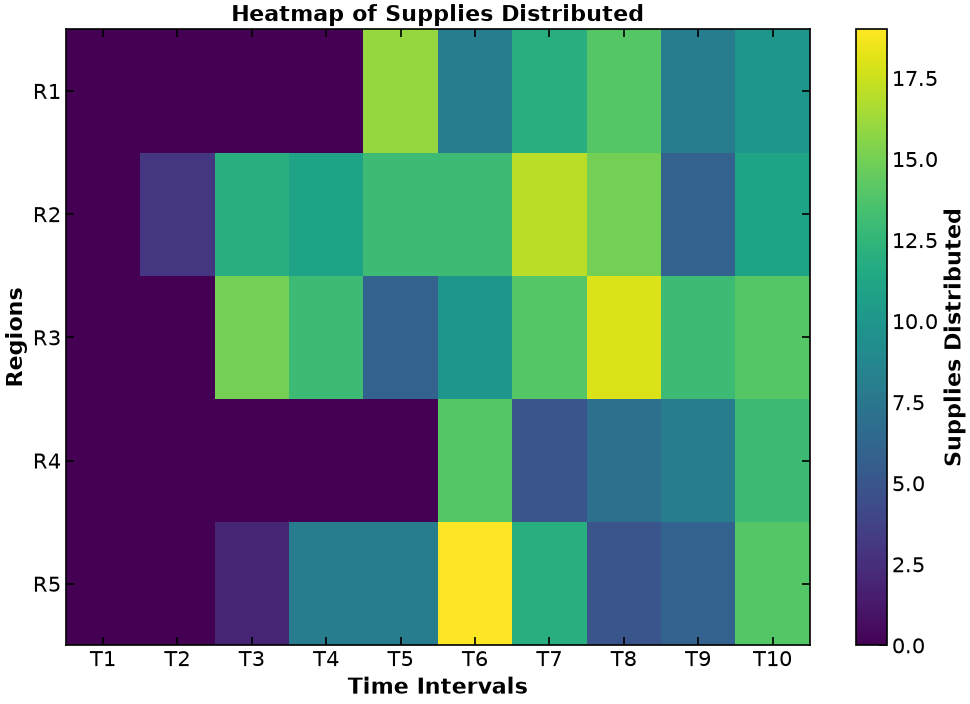

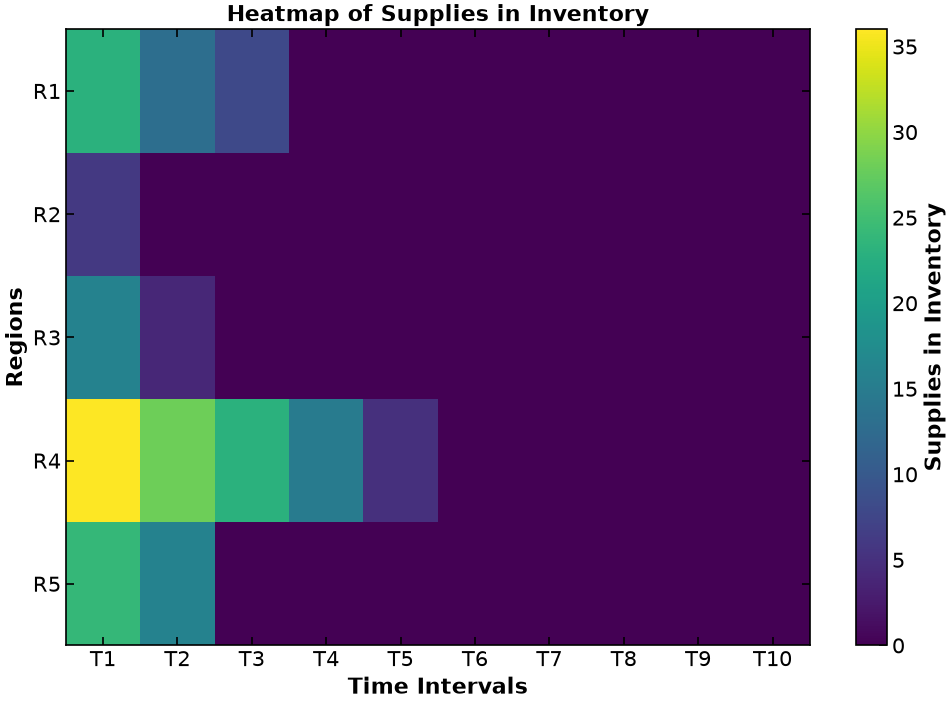

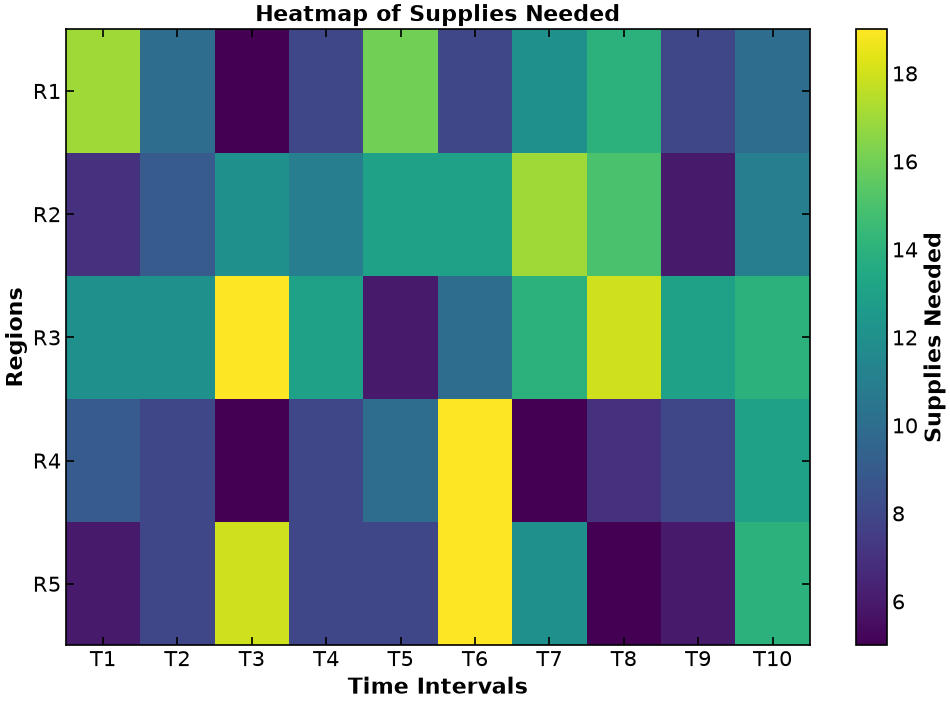

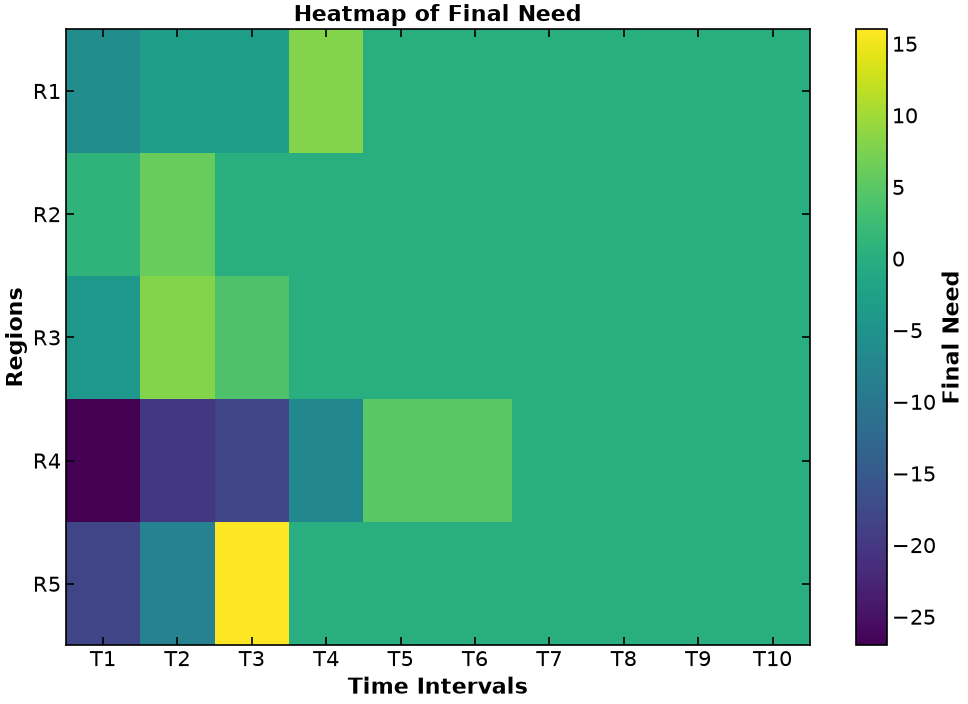

In [8]:
# Initial testing data
N_R = 5  # num of regions
N_t = 10  # num of time intervals
S_needed_data = {
    (k, t): np.random.randint(5, 20)
    for k in range(1, N_R + 1)
    for t in range(1, N_t + 1)
}
d_data = {
    (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
}
p_data = {k: float(np.random.random()) for k in range(1, N_R + 1)}
I_initial_data = {k: np.random.randint(10, 50) for k in range(1, N_R + 1)}

# creating model
model = m_model(S_needed_data, d_data, p_data, I_initial_data, N_t=N_t, N_R=N_R)

# Mapping supplies distributed, inventory, needed, and final heatmaps
supplies_distributed = plot_heatmap(dist_array, model)
inventory = plot_heatmap(inventory_array, model)
needed = plot_heatmap(needed_array, model)
final = plot_heatmap(final_array, model)

**Supplies Distributed**: The heatmap reveals a highly dynamic allocation of supplies across regions and time intervals. Certain regions and times received significantly higher distributions (indicated by bright yellow areas), which align with periods of elevated need or prioritization. This suggests that critical demands were met in these instances. However, some regions consistently received lower supplies, which highlights areas with reduced urgency or lower demand levels.

**Supplies in Inventory**: The inventory heatmap shows that supplies in stock decrease sharply in regions and times of high distribution activity. On the other hand, regions with less immediate demand or lower prioritization maintain higher inventory levels.

**Supplies Needed**: The supplies needed heatmap confirms the variability of demand across regions and time intervals. The bright areas (indicating higher needs) coincide with regions and times that received higher supplies in the distribution heatmap. This alignment suggests the system's responsiveness to actual demand. However, the scattered bright areas also highlight that demand is not uniform.

**Final Need**: The heatmap of final unmet need reveals areas where the model succeeded in meeting demand (dark regions) versus areas with residual unmet need (lighter regions). In most cases, unmet needs are minimal, indicating efficient resource allocation. However, regions with persistent lighter areas highlight potential gaps in distribution, which could be due to constraints like supply limits or prioritization criteria.

## Sensitivity Analysis via Monte Carlo Simulations

This project employs Monte Carlo simulations to explore the variability and sensitivity of our disaster response model across a range of different possible scenarios. This involves randomly varying key input parameters—such as supply needs, danger levels, and resource availability—within predefined ranges to mimic realistic conditions.

In [9]:
import numpy as np

# import plotly.express as px

N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    S_needed_data = {
        (k, t): np.random.randint(*S_needed_range)
        for k in range(1, N_R + 1)
        for t in range(1, N_t + 1)
    }
    d_data = {
        (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
    }
    p_data = {k: np.random.random() for k in range(1, N_R + 1)}
    I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))

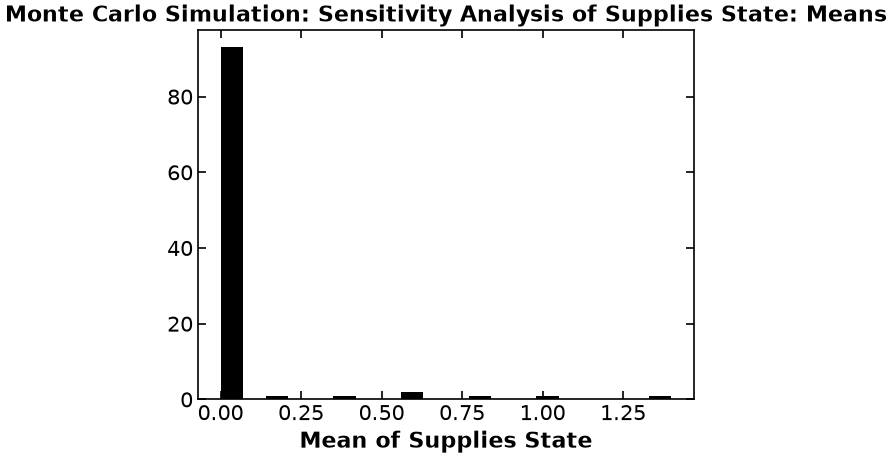

In [10]:
# creating histogram of sensitivity results
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis of Supplies State: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()
plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis of Supplies State: Means")
plt.xlabel("Mean of Supplies State")
plt.show()

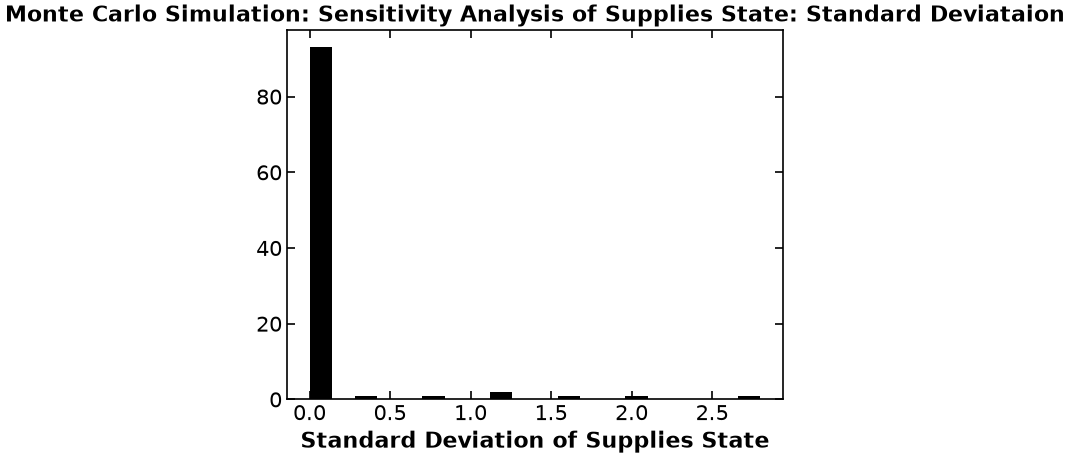

In [11]:
# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis of Supplies State: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()
plt.hist(results_std, bins=20)
plt.title(
    "Monte Carlo Simulation: Sensitivity Analysis of Supplies State: Standard Deviataion"
)
plt.xlabel("Standard Deviation of Supplies State")
plt.show()

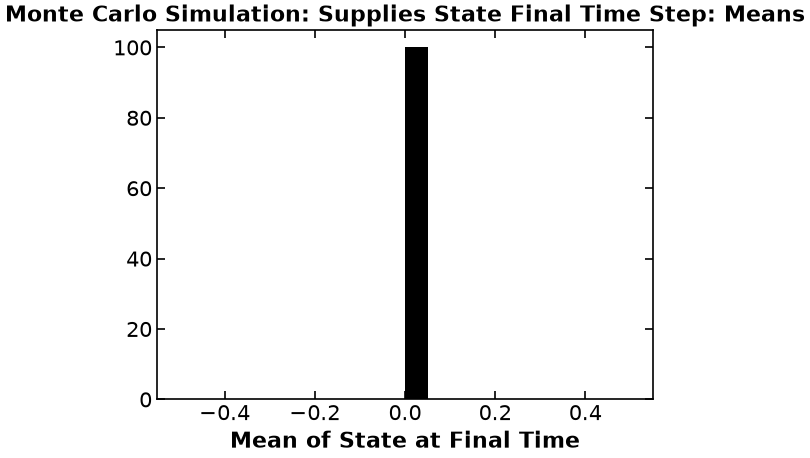

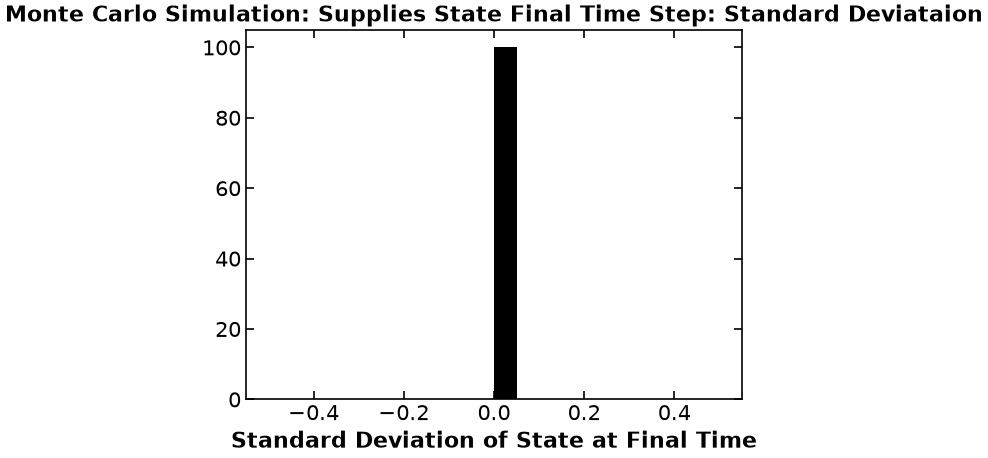

In [12]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    S_needed_data = {
        (k, t): np.random.randint(*S_needed_range)
        for k in range(1, N_R + 1)
        for t in range(1, N_t + 1)
    }
    d_data = {
        (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
    }
    p_data = {k: np.random.random() for k in range(1, N_R + 1)}
    I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the last col
    col = final[:, -1]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))


# Analyze the results
# fig = px.histogram(x=sensitivity_results,  title='Monte Carlo Simulation: Supplies State Final: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()
plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Supplies State Final Time Step: Means")
plt.xlabel("Mean of State at Final Time")
plt.show()

# fig_s = px.histogram(x=results_std, title='Monte Carlo Simulation: Supplies State Final Time Step: Standard Deviataion')
# make the bars thinner
# fig_s.show()
plt.hist(results_std, bins=20)
plt.title("Monte Carlo Simulation: Supplies State Final Time Step: Standard Deviataion")
plt.xlabel("Standard Deviation of State at Final Time")
plt.show()

## Insights

The first two graphs show a Monte Carlo Simulation on need met described as the need a region has subtracted by the inventory of supplies it has and distribution it recieves. Therefore a negative value means need has been more than met and a positive value means need is still not met. This simulation is based on the middle timetep to see how the model is responding at the half-way point.

The mean graph shows a slightly binominal distribution which makes sense because at the halfway point, some neeed may still not be met in regions while in others it may be. The variability is also very high as seen in the standard deviation graph meaning the model is very sensitive to inputs. We can dive deeper into what inputs it is sensitive to.

The last graph shows the same mean and standard deviation as above but for the last timestep. What we can see here is that mean and standard deviation are 0 which means that by the final timestep, need has been met and there is low variability.

## Diving Deeper

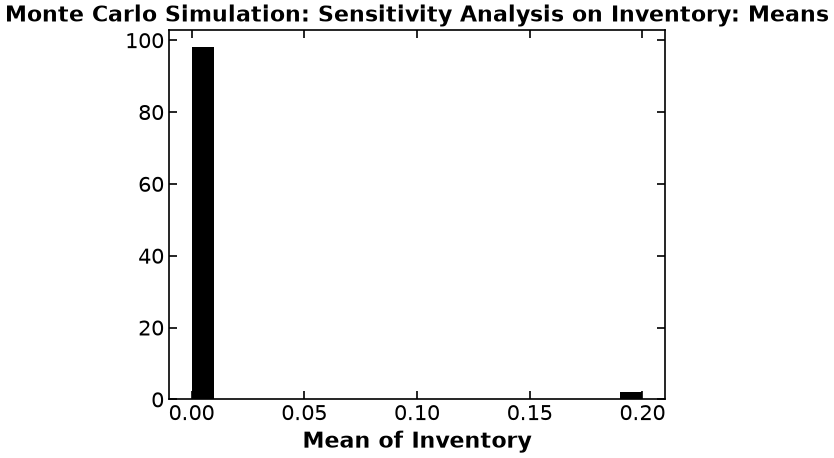

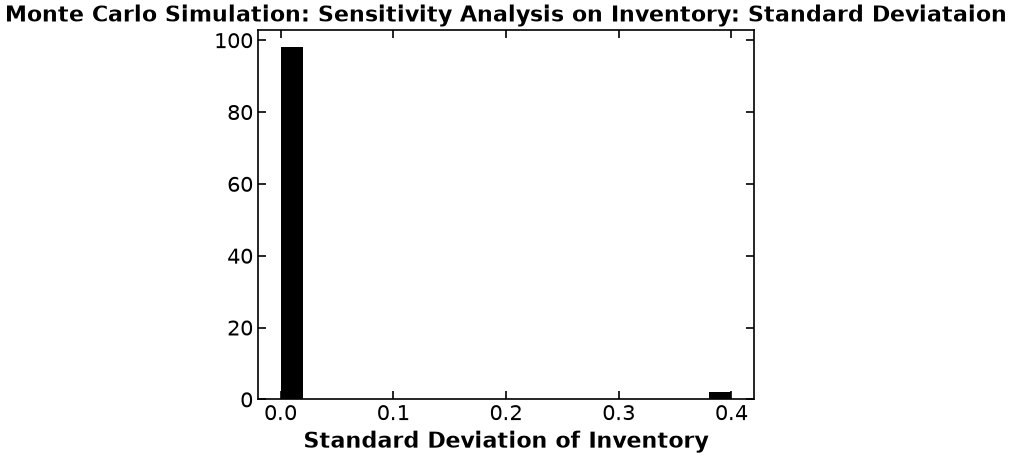

In [13]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
S_needed_data = {
    (k, t): np.random.randint(*S_needed_range)
    for k in range(1, N_R + 1)
    for t in range(1, N_t + 1)
}
d_data = {
    (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
}
p_data = {k: np.random.random() for k in range(1, N_R + 1)}
# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))

# Analyze the results
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Inventory: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()
plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Inventory: Means")
plt.xlabel("Mean of Inventory")
plt.show()

# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Inventory: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()
plt.hist(results_std, bins=20)
plt.title(
    "Monte Carlo Simulation: Sensitivity Analysis on Inventory: Standard Deviataion"
)
plt.xlabel("Standard Deviation of Inventory")
plt.show()

The graph is more normally distributed when just inventory is being changed at each timestep. This means that when inventory is changing while the other three inputs are kept stable, the model is able meet need much better. However, the standard deviation is still high which means there is still high variability and so, the inventory is causing high variability in the model.

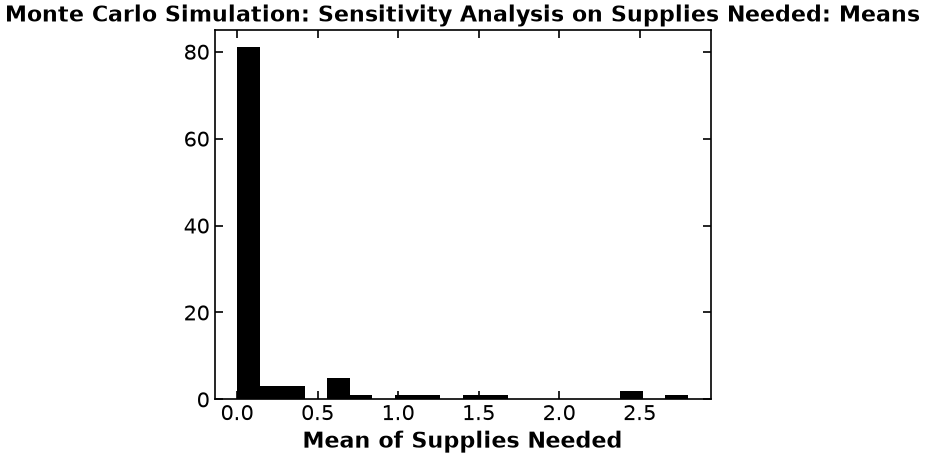

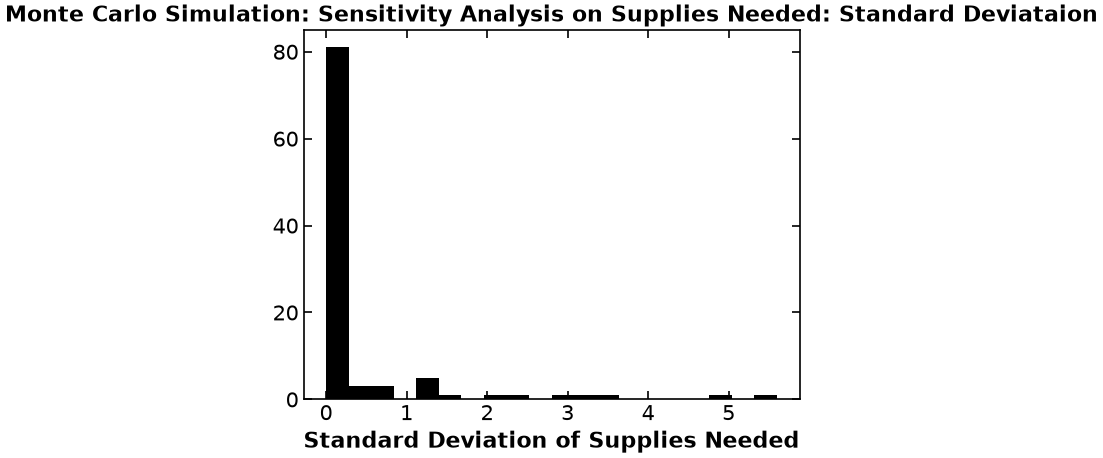

In [14]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
d_data = {
    (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
}
p_data = {k: np.random.random() for k in range(1, N_R + 1)}
I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}

# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    S_needed_data = {
        (k, t): np.random.randint(*S_needed_range)
        for k in range(1, N_R + 1)
        for t in range(1, N_t + 1)
    }

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))
# Analyze the results
##send the text output to another
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Supplies Needed: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()

plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Supplies Needed: Means")
plt.xlabel("Mean of Supplies Needed")
plt.show()

# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Supplies Needed: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()

plt.hist(results_std, bins=20)
plt.title(
    "Monte Carlo Simulation: Sensitivity Analysis on Supplies Needed: Standard Deviataion"
)
plt.xlabel("Standard Deviation of Supplies Needed")
plt.show()

Again, the graph is more normally distributed when just supplies needed is being changed at each timestep. This means that when supplies needed is changing while the other three inputs are kept stable, the model is able meet need much better. However, the standard deviation is still high which means there is still high variability and so, supplies needed is causing high variability in the model.

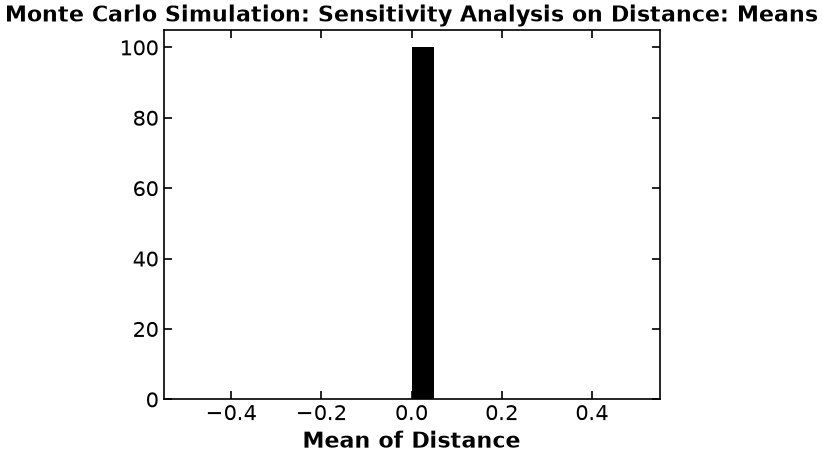

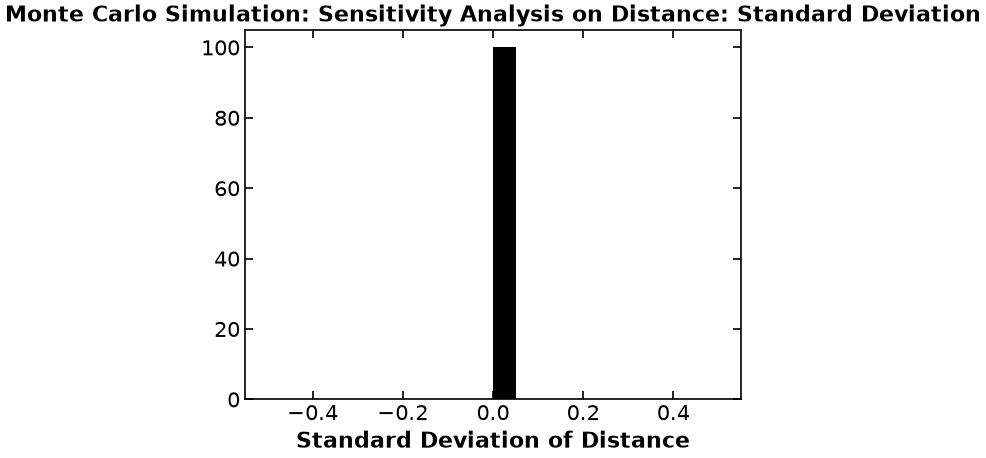

In [15]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
d_data = {
    (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
}
I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}
S_needed_data = {
    (k, t): np.random.randint(*S_needed_range)
    for k in range(1, N_R + 1)
    for t in range(1, N_t + 1)
}

# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    p_data = {k: np.random.random() for k in range(1, N_R + 1)}

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))
# Analyze the results
##send the text output to another
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Distance: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()

plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Distance: Means")
plt.xlabel("Mean of Distance")
plt.show()

# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Supplies Distance: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()

plt.hist(results_std, bins=20)
plt.title(
    "Monte Carlo Simulation: Sensitivity Analysis on Distance: Standard Deviation"
)
plt.xlabel("Standard Deviation of Distance")
plt.show()

When position of different regions is changing while the 3 other inputs are kept stable, the mean graph shows that need is not being met. Because the variability is so low, this means that position is not affecting the model as much as the other 3 inputs.

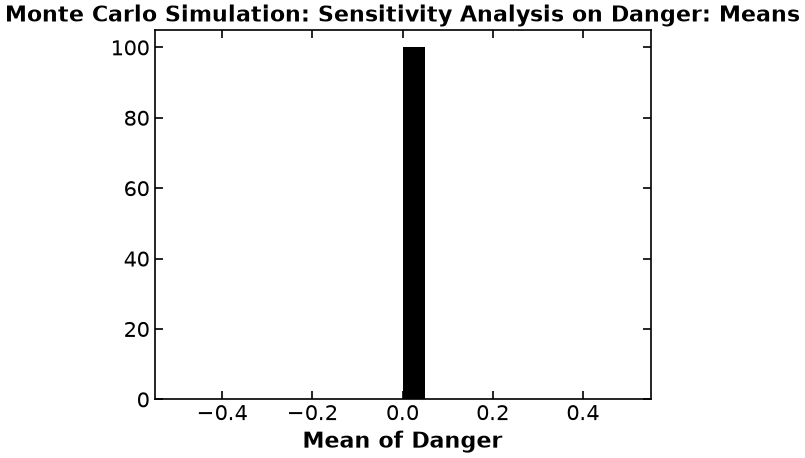

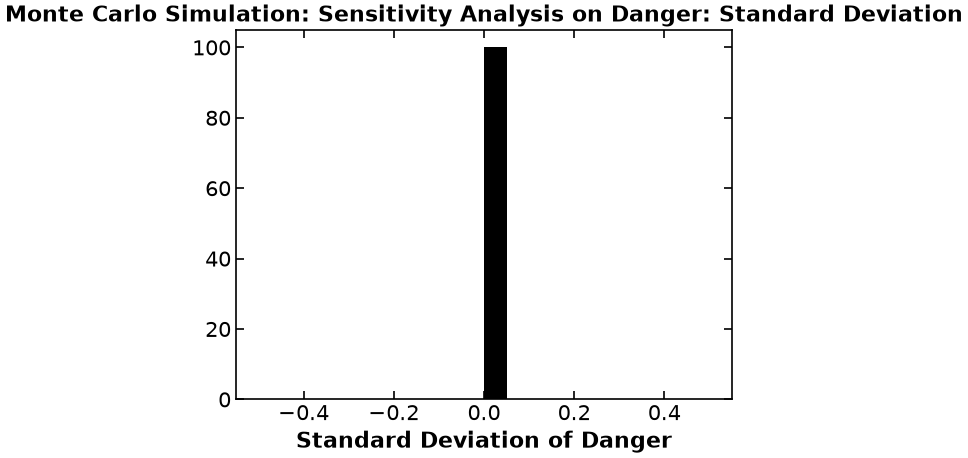

In [16]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []
p_data = {k: np.random.random() for k in range(1, N_R + 1)}
I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}
S_needed_data = {
    (k, t): np.random.randint(*S_needed_range)
    for k in range(1, N_R + 1)
    for t in range(1, N_t + 1)
}

# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    d_data = {
        (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
    }

    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [
                pyo.value(model.S[k, t])
                - pyo.value(model.I[k, t])
                - pyo.value(model.x[k, t])
                for t in range(1, N_t + 1)
            ]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))
# Analyze the results
##send the text output to another
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Danger: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()

plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Danger: Means")
plt.xlabel("Mean of Danger")
plt.show()

# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Danger: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()

plt.hist(results_std, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Danger: Standard Deviation")
plt.xlabel("Standard Deviation of Danger")
plt.show()

When danger of different regions is changing while the 3 other inputs are kept stable, the mean graph shows that need is not being met. Because the variability is so low, this means that danger is not affecting the model as much as the other 3 inputs.

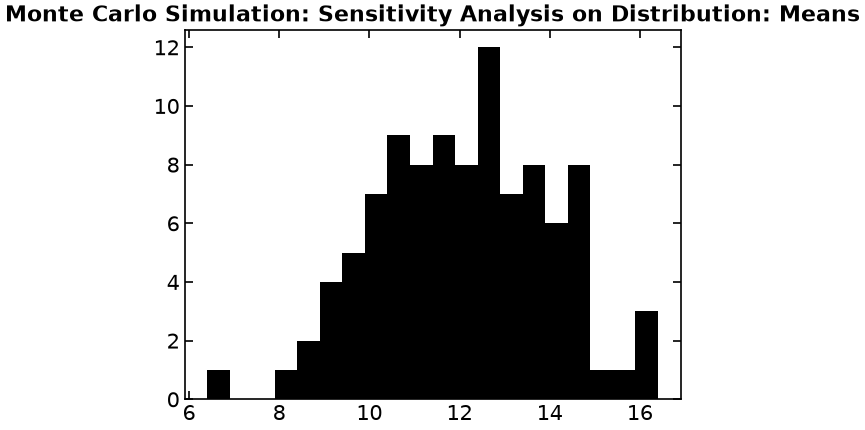

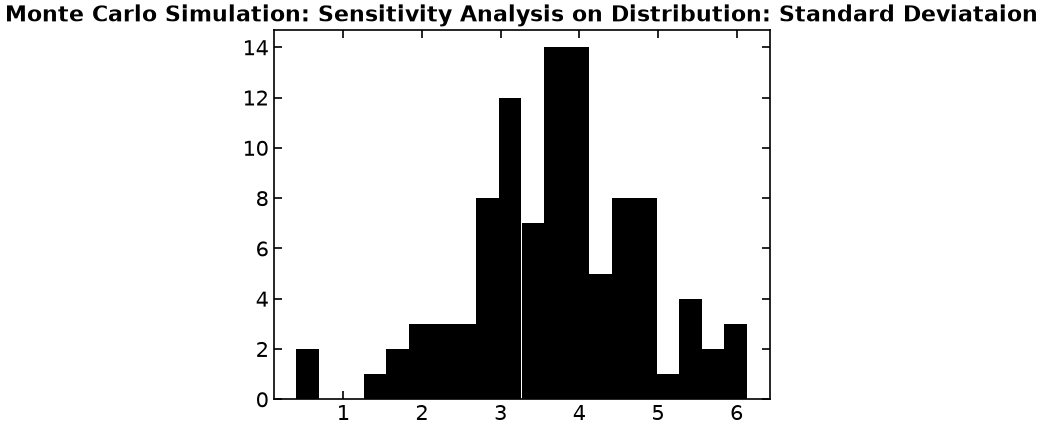

In [17]:
N_R = 5  # num of regions
N_t = 10  # num of time intervals

# Number of simulations
n_simulations = 100

# Define the ranges for random sampling
S_needed_range = (5, 20)
d_range = (0, 1)  # assuming uniform random between 0 and 1
p_range = (0, 1)
I_initial_range = (10, 50)

# Store results
sensitivity_results = []
results_std = []

# Perform Monte Carlo simulations
for _ in range(n_simulations):
    # Sample random values for each parameter
    I_initial_data = {k: np.random.randint(*I_initial_range) for k in range(1, N_R + 1)}
    S_needed_data = {
        (k, t): np.random.randint(*S_needed_range)
        for k in range(1, N_R + 1)
        for t in range(1, N_t + 1)
    }
    d_data = {
        (k, t): np.random.random() for k in range(1, N_R + 1) for t in range(1, N_t + 1)
    }
    p_data = {k: np.random.random() for k in range(1, N_R + 1)}
    # Run the model with the sampled inputs
    model = m_model(
        S_needed_data,
        d_data,
        p_data,
        I_initial_data,
        N_t=N_t,
        N_R=N_R,
        print_verbose=False,
    )

    # Extract the output of interest (e.g., supplies final)

    final = np.array(
        [
            [pyo.value(model.x[k, t]) for t in range(1, N_t + 1)]
            for k in range(1, N_R + 1)
        ]
    )

    # use the middle column in final
    col = final[:, N_t // 2]
    # Save some statistic (e.g., mean of the supplies final)
    sensitivity_results.append(np.mean(col))
    results_std.append(np.std(col))
# Analyze the results
##send the text output to another
# fig = px.histogram(x=sensitivity_results, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Distribution: Means')
# make the bars thinner
# fig.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig.show()

plt.hist(sensitivity_results, bins=20)
plt.title("Monte Carlo Simulation: Sensitivity Analysis on Distribution: Means")
plt.show()

# fig_s = px.histogram(x=results_std, nbins=20, title='Monte Carlo Simulation: Sensitivity Analysis on Distribution: Standard Deviataion')
# make the bars thinner
# fig_s.update_traces(marker_line_width=0.5)
# fig.update_layout(bargap=0.2)
# fig_s.show()
plt.hist(results_std, bins=20)
plt.title(
    "Monte Carlo Simulation: Sensitivity Analysis on Distribution: Standard Deviataion"
)
plt.show()

The graph above is calculating the average and standard deviations of distributions that regions recieve. This graph still shows a slightly binomial distribution with peaks around 6 and 13. Overall the standard deviation graph is still very high meaning that like the overall need met, the distribution graph is still sensitive to the 4 inputs.

To validate the model, this sensitivity analysis was conducted through utilizing Monte Carlo simulations. The result reveals the variability in the average supplies distributed across regions and time intervals under uncertain input parameters such as supply needs, danger levels, positional priorities, and initial inventories. The histogram of results highlights a distribution centered near zero. This indicates that, on average, the optimization model balances supply and demand effectively. However, the spread of the results reflects the influence of random fluctuations in the parameters, suggesting that certain scenarios may lead to significant deviations in supplies allocated to regions. This variability underscores the significance of robust planning in disaster response scenarios, where uncertainties in demand, resource availability, and prioritization can significantly impact the overall system performance.

## Discussion

Through this example, we were able to go beyond the reference material, by creating a new and unique application of the optimization problem. By applying this to a real life situation, we were able to create a simplified model to represent a real life situation that could be expanded to create real social good.

For example, government planning can be used to understand based on existing data, what regions to distribute to which can expediate the process.

Future Work Ideas:
* Refine the Monte Carlo sensitivity analysis
* Adjust input data such that there will be a supply shortage at the final time